# Systems, sources, spectra, and detectors

This tutorial explains the high-level dLux modelling contract: a `Source` propagated through an `OpticalSystem` produces a `PSF`; a `DetectorSystem` transforms that prediction into an expected `Image`; and `Image.simulate()` produces a noisy exposure with uncertainty metadata. It focuses on object ownership, physical units, array shapes, vectorisation, and deterministic versus stochastic behaviour rather than repeating the inference workflow from getting started.

The tutorial has six stages:

1. **Build an optical system.** Combine a sampled pupil and focal propagator in a named `OpticalSystem`. Explain layer order, the initial pupil grid, raised attributes and parameter paths, direct `propagate()` calls, equivalent `source.model(optics)` and `optics.model(source)` syntax, and intermediate inspection through debugging or `return_all`.
2. **Define sources and spectra.** Progress from a monochromatic point source to a polychromatic source with explicit weights, `SpectralPolynomial`, `Blackbody`, or `SpectralBasis` behaviour. State the `(x, y)` position convention, scalar-wavelength promotion, photon-flux defaults, `log` and `ln` flux units, convenient input-unit conversion, spectral-coordinate normalisation, and the separation between total flux and spectral shape.
3. **Vectorise a stellar scene.** Construct one `Source` containing several stars with positions of shape `(nsource, 2)`, per-source log fluxes, temperatures, and spectral weights. Show that dLux propagates and incoherently combines the sources without manual vmapping. Briefly compare this general representation with `BinarySource`, which exposes centre, separation, position angle, and contrast for a physically binary scene.
4. **Apply a detector system.** Build an ordered deterministic chain from pixel response, jitter, background, and saturation layers. Inspect the expected image after each stage and explain why layer order matters. These differentiable transformations belong to the detector model; random photon and read noise do not.
5. **Simulate an exposure.** Convert the detector output into an `Image` with read noise and call `.simulate(key, n_frames=...)`. Compare the optical PSF, expected detector image, noisy exposure, and exposure standard deviation. Explain that repeated frames are averaged, the stored variance belongs to that mean, and `error`, `z_score()`, and `log_likelihood()` use the image-owned uncertainty contract.
6. **Inspect the complete model.** Assemble the vectorised scene, optical system, detector system, and exposure in one compact workflow. Inspect representative source, optical, and detector parameter paths and finish with the ownership boundary: sources describe the sky, optical systems propagate fields, detector systems apply deterministic measurement effects, and images own stochastic observation metadata. Custom observation classes are useful for complex inference, but are not required for ordinary modelling.

The closing summary maps physical questions to `Source`, `BinarySource`, `OpticalSystem`, `PSF`, `DetectorSystem`, and `Image`. This tutorial complements getting started by explaining the unit, shape, spectral, vectorisation, and ownership contracts underlying that end-to-end fit, without adding another optimisation example.

In [1]:
import jax.numpy as np
import jax.random as jr

import dLux as dl
import dLux.utils as dlu

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 90

## Building an optical system

An `OpticalSystem` is an ordered collection of optical layers plus the `GridSpec` used to initialise its input wavefront. Propagation to another plane is explicit: here the final `Fraunhofer` layer maps the metre-sampled pupil onto an angular focal-plane grid.

In [2]:
# Pupil and focal-plane sampling
wf_npix = 256
diameter = 1.0
oversample = 2
psf_npix = 64
psf_pixel_scale = 0.05

pupil_spec = dl.GridSpec(n=(wf_npix,) * 2, diam=diameter, unit="m")
psf_spec = dl.GridSpec(
    n=(psf_npix * oversample,) * 2,
    d=psf_pixel_scale / oversample,
    unit="arcsec",
)

# A simple obscured pupil
coordinates = pupil_spec.coordinates
primary = dlu.circle(coordinates, diameter)
secondary = dlu.circle(coordinates, 0.2 * diameter, invert=True)
aperture = primary * secondary

# Optical layers are applied in their listed order
layers = [
    ("pupil", dl.Optic(transmission=aperture, normalise=True)),
    ("propagator", dl.Fraunhofer(psf_spec)),
]
optics = dl.OpticalSystem(layers, pupil_spec)
print(optics)

OpticalSystem(
  layers={
    'pupil':
    Optic(opd=None, phase=None, transmission=f32[256,256], normalise=True),
    'propagator':
    Fraunhofer(
      grid=GridSpec(n=(128, 128), d=f32[2], c=None, unit='arcsec'),
      focal_length=None,
      inverse=False,
      method='mft'
    )
  },
  grid=GridSpec(n=(256, 256), d=f32[2], c=None, unit='m')
)


## Sources and spectra

A `Spectrum` contains wavelength samples and their corresponding weights. A `Source` adds position, flux, and an optional resolved distribution. Units are declared once on the source, so user-facing values can remain convenient. Explicit array weights are treated as pre-integrated and are not automatically normalised. Parametric spectral models such as `SpectralPolynomial`, `SpectralBasis`, and `Blackbody` provide a `normalise` option and use unit-sum weights by default. This normalization is applied independently along the trailing wavelength axis and treats samples as equally weighted bins; nonuniform wavelength samples require explicit bin widths or quadrature weights. Realized weights must be positive with a finite, non-zero sum.

In [3]:
# A mildly red spectrum sampled in nanometres
wavelengths = np.linspace(850, 1050, 9)
weights = np.linspace(0.6, 1.4, wavelengths.size)
weights /= weights.sum()

# A point source 100 mas off axis with 2e5 photons
source = dl.Source(
    wavelengths,
    position=np.array([100.0, 0.0]),
    flux=2e5,
    weights=weights,
    units={"wavelengths": "nm", "position": "mas"},
)
print(source)

Source(
  wavelengths=f32[9],
  weights=f32[9],
  units={
    'wavelengths': 'nm',
    'position': 'mas',
    'flux': 'photon',
    'distribution': 'linear'
  },
  flux=f32[],
  distribution=None,
  position=f32[2]
)


## Wavefront and PSF states

`source.wavefront(spec)` constructs the incident field directly from the source spectrum, flux, and position. It is useful for custom wavefront workflows; any later normalising optical layer will intentionally reset its power. Resolved source distributions remain image-plane operations in `source.model`. `OpticalSystem.model` returns a `PSF` by default, while `return_all=True` also exposes the final chromatic `Wavefront`. The wavefront retains the complex electric field for every wavelength; the PSF contains their weighted intensity sum and its focal-plane sampling.

In [4]:
input_wavefront = source.wavefront(pupil_spec)
result = optics.model(source, return_all=True)
wavefront = result["Wavefront"]
psf = result["PSF"]

print(input_wavefront)
print(wavefront)
print(psf)
print("Wavefront phasor:", wavefront.phasor.shape)
print("PSF data:", psf.data.shape)

Wavefront(
  grid=GridSpec(n=(256, 256), d=f32[2], c=None, unit='m'),
  phasor=c64[9,256,256],
  wavelength=f32[9]
)
Wavefront(
  grid=GridSpec(n=(128, 128), d=f32[2], c=None, unit='arcsec'),
  phasor=c64[9,128,128],
  wavelength=f32[9]
)
PSF(
  grid=GridSpec(n=(128, 128), d=f32[2], c=None, unit='arcsec'),
  data=f32[128,128]
)
Wavefront phasor: (9, 128, 128)
PSF data: (128, 128)


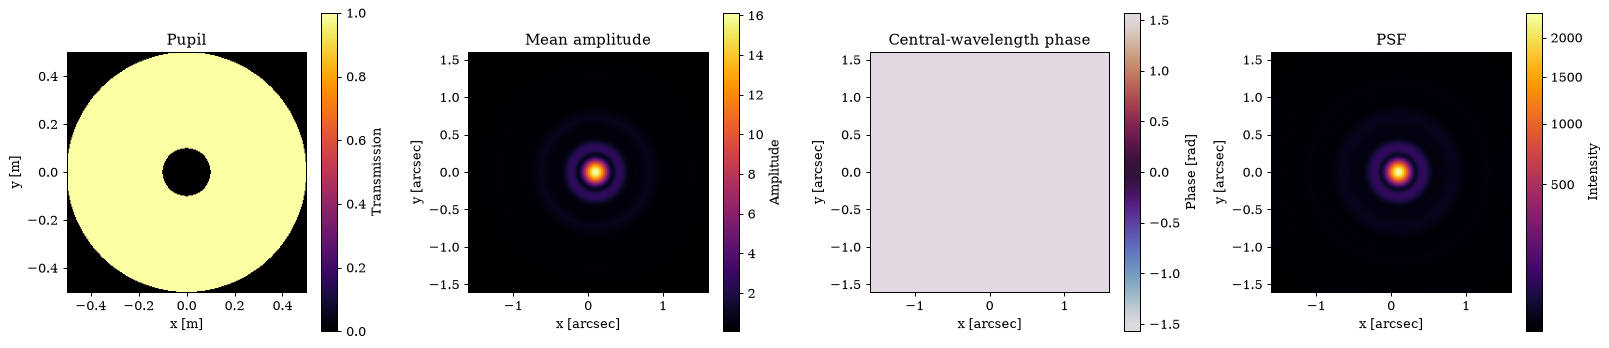

In [5]:
## COLLAPSE: Plotting code
pupil_extent = pupil_spec.extent()
psf_extent = psf_spec.extent(unit="arcsec")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
images = [
    axes[0].imshow(aperture, extent=pupil_extent),
    axes[1].imshow(wavefront.amplitude.mean(0), extent=psf_extent),
    axes[2].imshow(wavefront.phase[4], cmap="twilight", extent=psf_extent),
    axes[3].imshow(psf.data, norm=PowerNorm(0.5), extent=psf_extent),
]
titles = ["Pupil", "Mean amplitude", "Central-wavelength phase", "PSF"]
labels = ["Transmission", "Amplitude", "Phase [rad]", "Intensity"]
for ax, image, title, label in zip(axes, images, titles, labels):
    ax.set_title(title)
    plt.colorbar(image, ax=ax, label=label)
axes[0].set(xlabel="x [m]", ylabel="y [m]")
for ax in axes[1:]:
    ax.set(xlabel="x [arcsec]", ylabel="y [arcsec]")
plt.tight_layout()
plt.show()

A `BinarySource` uses the same spectral contract while generating two positions and their flux ratio. Its weights may be shared by both stars or have a leading two-source axis for distinct component spectra.

In [6]:
binary_weights = np.stack((weights, weights[::-1]))
binary = dl.BinarySource(
    wavelengths,
    centre=np.zeros(2),
    separation=250.0,
    position_angle=np.deg2rad(30.0),
    contrast=4.0,
    flux=2e5,
    weights=binary_weights,
    units={"wavelengths": "nm", "position": "mas"},
)
binary_psf = optics.model(binary)
print(binary)
print(binary_psf)

BinarySource(
  wavelengths=f32[9],
  weights=f32[2,9],
  units={
    'wavelengths': 'nm',
    'position': 'mas',
    'flux': 'photon',
    'distribution': 'linear'
  },
  flux=f32[],
  distribution=None,
  centre=f32[2],
  separation=f32[],
  position_angle=f32[],
  contrast=f32[]
)
PSF(
  grid=GridSpec(n=(128, 128), d=f32[2], c=None, unit='arcsec'),
  data=f32[128,128]
)


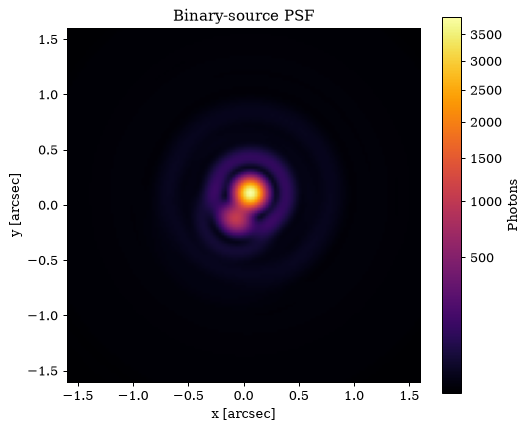

In [7]:
## COLLAPSE: Plotting code
plt.figure(figsize=(6, 5))
image = plt.imshow(binary_psf.data, norm=PowerNorm(0.5), extent=psf_extent)
plt.colorbar(image, label="Photons")
plt.title("Binary-source PSF")
plt.xlabel("x [arcsec]")
plt.ylabel("y [arcsec]")
plt.tight_layout()
plt.show()

## Detector systems and images

A `DetectorSystem` accepts a `PSF` and returns an `Image`. This cleanly separates continuous optical modelling from detector sampling. Here we downsample the oversampled PSF, apply jitter, and add a constant background. The resulting `Image` can then generate noise realisations and track their variance.

In [8]:
detector = dl.DetectorSystem(
    [
        ("downsample", dl.Downsample(oversample)),
        ("jitter", dl.ApplyJitter(sigma=0.35)),
        ("background", dl.AddConstant(5.0)),
    ]
)

image = detector.model(psf)
key_poisson, key_read = jr.split(jr.key(0))
noisy = image.add_poisson_noise(key_poisson).add_read_noise(key_read, sigma=3.0)

print(detector)
print(image)
print(noisy)

DetectorSystem(
  layers={
    'downsample': Downsample(n=(2,)),
    'jitter': ApplyJitter(sigma=f32[], kernel_size=9, oversample=3),
    'background': AddConstant(value=f32[])
  }
)
Image(
  grid=GridSpec(n=(64, 128), d=f32[2], c=None, unit='arcsec'),
  data=f32[128,64],
  variance=None,
  read_noise=f32[]
)
Image(
  grid=GridSpec(n=(64, 128), d=f32[2], c=None, unit='arcsec'),
  data=f32[128,64],
  variance=f32[128,64],
  read_noise=f32[]
)


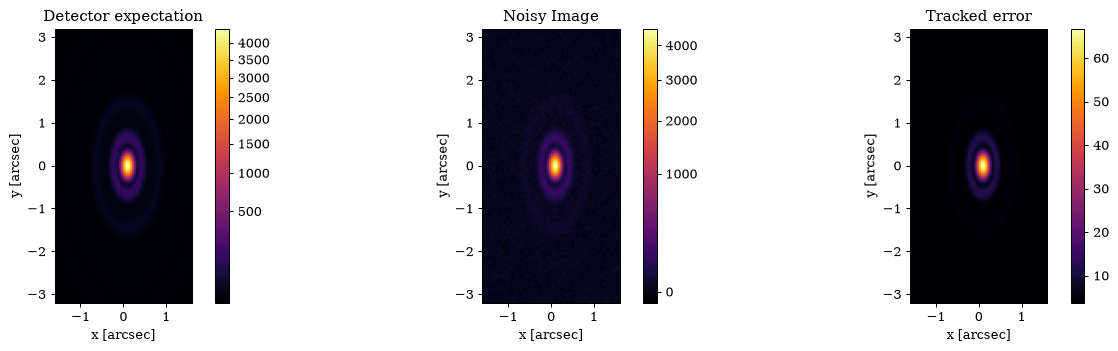

In [9]:
## COLLAPSE: Plotting code
image_extent = image.grid.extent(unit="arcsec")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    (image.data, "Detector expectation", PowerNorm(0.5)),
    (noisy.data, "Noisy Image", PowerNorm(0.5)),
    (noisy.error, "Tracked error", None),
]
for ax, (data, title, norm) in zip(axes, panels):
    im = ax.imshow(data, extent=image_extent, norm=norm)
    plt.colorbar(im, ax=ax)
    ax.set(title=title, xlabel="x [arcsec]", ylabel="y [arcsec]")
plt.tight_layout()
plt.show()

## Summary

The class boundaries now mirror the physical modelling flow:

1. `Source` and `Spectrum` define incident light.
2. `OpticalSystem.model(source)` returns a continuous `PSF`.
3. `DetectorSystem.model(psf)` returns a detector-sampled `Image`.

Use `return_all=True` when access to the propagated `Wavefront` is also required.